# CC3092 - Laboratorio 7 - Task 3

Transformer encoder (una capa) con multi-head self-attention implementado manualmente (sin `nn.MultiheadAttention`), entrenado para $H=24$ y $H=48$.

## Setup (reproduce el Task 1)

Este notebook es autocontenido: se repite el pipeline de `Lab7_Task1.ipynb` (normalizacion z-score de `OT`, split temporal 60/20/20 y ventanas con $L=96$, $H\in\{24,48\}$). La explicacion detallada de cada paso esta en el notebook del Task 1.

In [1]:
import json
import math
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(42)
np.random.seed(42)

URL = ("https://raw.githubusercontent.com/zhouhaoyi/"
       "ETDataset/main/ETT-small/ETTh1.csv")
DATA_PATH = Path("ETTh1.csv")
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

if not DATA_PATH.exists():
    urllib.request.urlretrieve(URL, DATA_PATH)

In [2]:
data = np.genfromtxt(DATA_PATH, delimiter=",", skip_header=1)
OT = data[:, -1].astype(np.float32)       # Variable objetivo: Oil Temperature
ALL = data[:, 1:].astype(np.float32)      # Las 7 variables numericas

# z-score: x_norm = (x - mu) / sigma  (mu y sigma se guardan para desnormalizar)
mu = OT.mean()
sigma = OT.std()
OT_norm = (OT - mu) / sigma

# Split temporal contiguo: [train 60% | val 20% | test 20%], sin mezclar.
N_total = len(OT_norm)
n_train = int(0.60 * N_total)
n_val = int(0.20 * N_total)
OT_train = torch.from_numpy(OT_norm[:n_train].copy())
OT_val = torch.from_numpy(OT_norm[n_train:n_train + n_val].copy())
OT_test = torch.from_numpy(OT_norm[n_train + n_val:].copy())


def make_windows(series, L, H):
    # X^(t) = (x_{t-L+1}, ..., x_t),  y^(t) = x_{t+H}
    series = torch.as_tensor(series, dtype=torch.float32).flatten()
    n_examples = series.numel() - L - H + 1
    X = series.unfold(dimension=0, size=L, step=1)[:n_examples].clone()
    start_y = L + H - 1
    y = series[start_y:start_y + n_examples].clone()
    return X, y


L = 96
X_tr_24, y_tr_24 = make_windows(OT_train, L=L, H=24)
X_vl_24, y_vl_24 = make_windows(OT_val,   L=L, H=24)
X_ts_24, y_ts_24 = make_windows(OT_test,  L=L, H=24)
X_tr_48, y_tr_48 = make_windows(OT_train, L=L, H=48)
X_vl_48, y_vl_48 = make_windows(OT_val,   L=L, H=48)
X_ts_48, y_ts_48 = make_windows(OT_test,  L=L, H=48)

# Baseline naive: y_hat = x_t (ultimo valor observado de la ventana)
naive_mae = torch.abs(y_vl_24 - X_vl_24[:, -1]).mean().item()
naive_mae_48 = torch.abs(y_vl_48 - X_vl_48[:, -1]).mean().item()

print(f"mu={mu:.4f}, sigma={sigma:.4f}")
print(f"train H=24: {tuple(X_tr_24.shape)}, val H=24: {tuple(X_vl_24.shape)}")
print(f"Naive MAE val: H=24 -> {naive_mae:.4f}, H=48 -> {naive_mae_48:.4f}")

mu=13.3247, sigma=8.5667
train H=24: (10333, 96), val H=24: (3365, 96)
Naive MAE val: H=24 -> 0.1996, H=48 -> 0.2604


## Task 3.1 - Positional encoding

$$\mathrm{PE}(t,2i)=\sin\!\left(\frac{t}{10000^{2i/d_{model}}}\right),\qquad \mathrm{PE}(t,2i+1)=\cos\!\left(\frac{t}{10000^{2i/d_{model}}}\right)$$

Cada escalar $x_t$ se proyecta a $\mathbb{R}^{d_{model}}$ con `nn.Linear(1, d_model)` y luego se le suma $\mathrm{PE}(t)$.

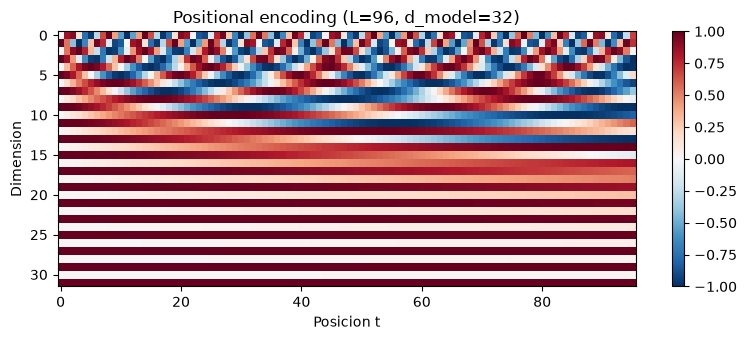

In [3]:
def make_pe(max_len, d_model):
    # SU CODIGO AQUI
    # t: (max_len, 1) posiciones; 2i: indices pares de la dimension
    t = torch.arange(max_len, dtype=torch.float32).unsqueeze(1)
    two_i = torch.arange(0, d_model, 2, dtype=torch.float32)
    div = torch.pow(10000.0, two_i / d_model)      # 10000^{2i/d_model}
    pe = torch.zeros(max_len, d_model)
    pe[:, 0::2] = torch.sin(t / div)               # PE(t, 2i)
    pe[:, 1::2] = torch.cos(t / div)               # PE(t, 2i+1)
    return pe                                      # (max_len, d_model), sin gradiente
    # FIN SU CODIGO


pe_demo = make_pe(96, 32)
fig, ax = plt.subplots(figsize=(8, 3.5))
im = ax.imshow(pe_demo.T, aspect="auto", cmap="RdBu_r")
ax.set(title="Positional encoding (L=96, d_model=32)", xlabel="Posicion t", ylabel="Dimension")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## Task 3.2 - `TransformerForecaster`

- Atencion por cabeza: $\mathrm{Attn}(Q,K,V)=\mathrm{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$, con $Q=XW_Q,\ K=XW_K,\ V=XW_V$.
- Multi-head: se concatenan las cabezas y se proyecta con $W_O$.
- LayerNorm: $\mathrm{LN}(x)=\gamma\odot\frac{x-\mu}{\sqrt{\sigma^2+\epsilon}}+\beta$ sobre la ultima dimension.
- FFN: $\mathrm{FFN}(x)=\mathrm{ReLU}(xW_1+b_1)W_2+b_2$.
- Bloque: Add & Norm despues de la atencion y despues de la FFN. La prediccion sale de la posicion 0 (token CLS).

In [4]:
class TransformerForecaster(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, L):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.L = L
        # SU CODIGO: declare los parametros
        # input_proj: nn.Linear(1, d_model)
        # WQ, WK, WV, WO: nn.Parameter de forma (d_model, d_model)
        # W1, b1: proyeccion FFN a d_ff
        # W2, b2: proyeccion FFN de vuelta a d_model
        # gamma1, beta1, gamma2, beta2: LayerNorm aprendible
        # W_out: nn.Linear(d_model, 1)

        # SU CODIGO AQUI
        # Proyeccion de entrada: escalar x_t -> R^{d_model}
        self.input_proj = nn.Linear(1, d_model)
        # PE fijo (buffer: se mueve con el modelo pero no se entrena)
        self.register_buffer("PE", make_pe(L, d_model))

        # Proyecciones de atencion (inicializacion Xavier)
        def xavier(*shape):
            return nn.Parameter(nn.init.xavier_uniform_(torch.empty(*shape)))
        self.WQ = xavier(d_model, d_model)
        self.WK = xavier(d_model, d_model)
        self.WV = xavier(d_model, d_model)
        self.WO = xavier(d_model, d_model)

        # FFN: d_model -> d_ff -> d_model
        self.W1 = xavier(d_model, d_ff)
        self.b1 = nn.Parameter(torch.zeros(d_ff))
        self.W2 = xavier(d_ff, d_model)
        self.b2 = nn.Parameter(torch.zeros(d_model))

        # LayerNorm aprendible (gamma=1, beta=0 al inicio)
        self.gamma1 = nn.Parameter(torch.ones(d_model))
        self.beta1 = nn.Parameter(torch.zeros(d_model))
        self.gamma2 = nn.Parameter(torch.ones(d_model))
        self.beta2 = nn.Parameter(torch.zeros(d_model))

        # Cabeza de regresion
        self.W_out = nn.Linear(d_model, 1)
        # FIN SU CODIGO

    def layer_norm(self, x, gamma, beta, eps=1e-5):
        # SU CODIGO: LayerNorm sobre la ultima dimension

        # SU CODIGO AQUI
        # LN(x) = gamma * (x - mu) / sqrt(var + eps) + beta, sobre la ultima dimension
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        return gamma * (x - mean) / torch.sqrt(var + eps) + beta
        # FIN SU CODIGO

    def multi_head_attention(self, x):
        """
        Parametros
        ----------
        x : Tensor (B, L, d_model)

        Retorna
        -------
        out     : Tensor (B, L, d_model)
        attn_w  : Tensor (B, n_heads, L, L): pesos de atencion

        Pasos:
        1. Proyectar con WQ, WK, WV: forma (B, L, d_model)
        2. Reshape a (B, L, n_heads, d_k) y transponer a (B, n_heads, L, d_k)
        3. scores = Q @ K^T / sqrt(d_k): forma (B, n_heads, L, L)
        4. attn_w = softmax(scores, dim=-1)
        5. out = attn_w @ V: forma (B, n_heads, L, d_k)
        6. Reshape a (B, L, d_model) y proyectar con WO
        """
        # SU CODIGO AQUI
        B, L, _ = x.shape
        # 1. Q = X WQ, K = X WK, V = X WV  -> (B, L, d_model)
        Q = x @ self.WQ
        K = x @ self.WK
        V = x @ self.WV
        # 2. Separar cabezas: (B, L, n_heads, d_k) -> (B, n_heads, L, d_k)
        Q = Q.view(B, L, self.n_heads, self.d_k).transpose(1, 2)
        K = K.view(B, L, self.n_heads, self.d_k).transpose(1, 2)
        V = V.view(B, L, self.n_heads, self.d_k).transpose(1, 2)
        # 3. scores e_ts = q_t^T k_s / sqrt(d_k)  -> (B, n_heads, L, L)
        scores = Q @ K.transpose(-2, -1) / math.sqrt(self.d_k)
        # 4. alpha_ts = softmax_s(e_ts): cada fila suma 1
        attn_w = torch.softmax(scores, dim=-1)
        # 5. z_t = sum_s alpha_ts v_s  -> (B, n_heads, L, d_k)
        out = attn_w @ V
        # 6. Concatenar cabezas -> (B, L, d_model) y proyectar con WO
        out = out.transpose(1, 2).contiguous().view(B, L, self.d_model)
        out = out @ self.WO
        return out, attn_w
        # FIN SU CODIGO

    def feed_forward(self, x):
        # SU CODIGO: FFN(x) = ReLU(x @ W1 + b1) @ W2 + b2

        # SU CODIGO AQUI
        return F.relu(x @ self.W1 + self.b1) @ self.W2 + self.b2
        # FIN SU CODIGO

    def forward(self, x, return_attn=False):
        """
        Parametros
        ----------
        x           : Tensor (B, L)
        return_attn : bool: si True, retorna tambien los pesos de atencion

        Retorna
        -------
        pred    : Tensor (B,)
        attn_w  : Tensor (B, n_heads, L, L): solo si return_attn=True

        Pasos:
        1. x = input_proj(x.unsqueeze(-1)) + PE[:L]   forma (B, L, d_model)
        2. att_out, attn_w = multi_head_attention(x)
        3. x = layer_norm(x + att_out, gamma1, beta1)   Add & Norm
        4. ff_out = feed_forward(x)
        5. x = layer_norm(x + ff_out, gamma2, beta2)    Add & Norm
        6. pred = W_out(x[:, 0, :]).squeeze(-1)   usar posicion 0 como CLS
        """
        # SU CODIGO AQUI
        B, L = x.shape
        # 1. Embedding + positional encoding -> (B, L, d_model)
        x = self.input_proj(x.unsqueeze(-1)) + self.PE[:L]
        # 2. Self-attention multi-cabeza
        att_out, attn_w = self.multi_head_attention(x)
        # 3. Add & Norm
        x = self.layer_norm(x + att_out, self.gamma1, self.beta1)
        # 4. Feed-forward
        ff_out = self.feed_forward(x)
        # 5. Add & Norm
        x = self.layer_norm(x + ff_out, self.gamma2, self.beta2)
        # 6. Prediccion desde la posicion 0 (CLS)
        pred = self.W_out(x[:, 0, :]).squeeze(-1)
        if return_attn:
            return pred, attn_w
        return pred
        # FIN SU CODIGO

## Task 3.3 - Entrenamiento, evaluacion y mapas de atencion

Mismas condiciones que el LSTM: 20 epocas, Adam, `batch_size=64`, MSE. Configuracion: `d_model=32, n_heads=2, d_ff=64, L=96`.

### Prediccion residual respecto al ultimo valor

El nivel de `OT` cambia entre splits (media normalizada de train $\approx +0.46$, de validacion $\approx -0.74$). Un modelo que predice el nivel absoluto aprende el nivel de train y generaliza mal. Por eso, con `RESIDUAL = True`, el modelo recibe la ventana centrada en su ultimo valor y predice el cambio:

$$\tilde X^{(t)} = X^{(t)} - x_t,\qquad \tilde y^{(t)} = x_{t+H} - x_t,\qquad \hat y^{(t)} = x_t + f_\theta(\tilde X^{(t)})$$

La clase del modelo no cambia; solo cambian la entrada y el objetivo. Con $f_\theta \equiv 0$ se recupera exactamente el baseline naive, asi que el modelo aprende una correccion sobre el.

In [5]:
RESIDUAL = True   # ver celda anterior; False = predecir el nivel absoluto x_{t+H}


def prepare(X, y=None):
    # X~ = X - x_t,  y~ = y - x_t  (si RESIDUAL); x_t = ultimo valor de cada ventana
    last = X[:, -1] if RESIDUAL else torch.zeros(X.shape[0])
    X_in = X - last.unsqueeze(1)
    y_in = None if y is None else y - last
    return X_in, y_in, last


def train_model(model, X, y, epochs=20, batch_size=64, lr=1e-3, loss_fn=None):
    # Entrenamiento con mini-batches y Adam. Se barajan las ventanas de train
    # (cada ventana es un ejemplo independiente); el split sigue siendo temporal.
    loss_fn = loss_fn or nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    X, y, _ = prepare(X, y)
    history = []
    n = X.shape[0]
    for epoch in range(1, epochs + 1):
        model.train()
        perm = torch.randperm(n)
        total = 0.0
        for start in range(0, n, batch_size):
            idx = perm[start:start + batch_size]
            optimizer.zero_grad()
            loss = loss_fn(model(X[idx]), y[idx])
            loss.backward()                    # gradientes via autograd (BPTT en el LSTM)
            optimizer.step()
            total += loss.item() * idx.numel()
        history.append(total / n)
        print(f"  epoca {epoch:2d}/{epochs}  loss={history[-1]:.5f}")
    return history


@torch.no_grad()
def predict(model, X, batch_size=512):
    # y_hat = x_t + f(X~)  (si RESIDUAL; si no, last = 0)
    model.eval()
    X_in, _, last = prepare(X)
    out = torch.cat([model(X_in[i:i + batch_size]) for i in range(0, X.shape[0], batch_size)])
    return out + last


def compute_metrics(y, pred, naive_mae_ref):
    # MAE = mean|y - y_hat|,  RMSE = sqrt(mean (y - y_hat)^2),  ratio = MAE / MAE_naive
    mae = torch.abs(y - pred).mean().item()
    rmse = torch.sqrt(((y - pred) ** 2).mean()).item()
    return {
        "mae": mae,
        "rmse": rmse,
        "ratio": mae / naive_mae_ref,
        # En grados Celsius: el error escala por sigma al desnormalizar
        "mae_C": mae * float(sigma),
        "rmse_C": rmse * float(sigma),
    }


def print_metrics(name, m):
    print(f"{name}: MAE={m['mae']:.4f} ({m['mae_C']:.3f} C) | "
          f"RMSE={m['rmse']:.4f} ({m['rmse_C']:.3f} C) | ratio vs naive={m['ratio']:.3f}")

In [6]:
EPOCHS, BATCH_SIZE, LR = 20, 64, 1e-3

print("Entrenando Transformer H=24")
torch.manual_seed(42)
trf_24 = TransformerForecaster(d_model=32, n_heads=2, d_ff=64, L=96)
trf_loss_24 = train_model(trf_24, X_tr_24, y_tr_24, EPOCHS, BATCH_SIZE, LR)

Entrenando Transformer H=24


  epoca  1/20  loss=0.14434


  epoca  2/20  loss=0.13146


  epoca  3/20  loss=0.13197


  epoca  4/20  loss=0.12984


...

  epoca 16/20  loss=0.12596


  epoca 17/20  loss=0.12580


  epoca 18/20  loss=0.12502


  epoca 19/20  loss=0.12534


  epoca 20/20  loss=0.12429


In [7]:
print("Entrenando Transformer H=48")
torch.manual_seed(42)
trf_48 = TransformerForecaster(d_model=32, n_heads=2, d_ff=64, L=96)
trf_loss_48 = train_model(trf_48, X_tr_48, y_tr_48, EPOCHS, BATCH_SIZE, LR)

Entrenando Transformer H=48


  epoca  1/20  loss=0.20891


  epoca  2/20  loss=0.19339


  epoca  3/20  loss=0.19051


  epoca  4/20  loss=0.18986


...

  epoca 16/20  loss=0.18208


  epoca 17/20  loss=0.17904


  epoca 18/20  loss=0.17848


  epoca 19/20  loss=0.17856


  epoca 20/20  loss=0.17776


Transformer H=24: MAE=0.1933 (1.656 C) | RMSE=0.2510 (2.150 C) | ratio vs naive=0.968
Transformer H=48: MAE=0.2475 (2.120 C) | RMSE=0.3070 (2.630 C) | ratio vs naive=0.950


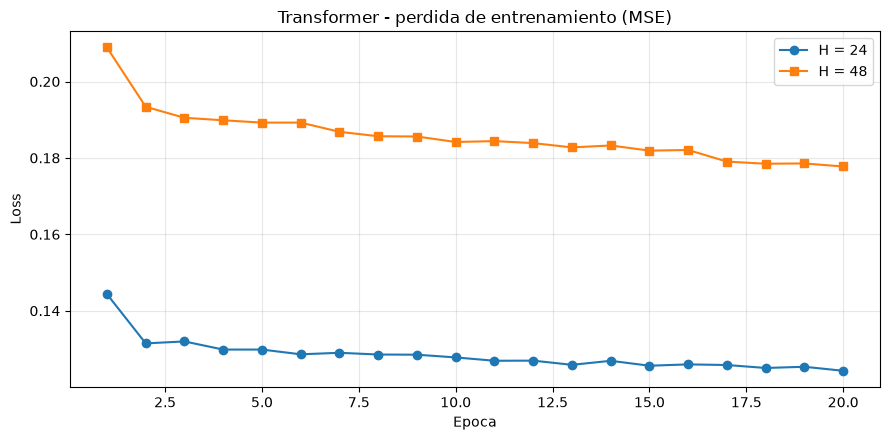

In [8]:
trf_pred_vl_24 = predict(trf_24, X_vl_24)
trf_pred_vl_48 = predict(trf_48, X_vl_48)

transformer_metrics = {
    "24": compute_metrics(y_vl_24, trf_pred_vl_24, naive_mae),
    "48": compute_metrics(y_vl_48, trf_pred_vl_48, naive_mae_48),
}
print_metrics("Transformer H=24", transformer_metrics["24"])
print_metrics("Transformer H=48", transformer_metrics["48"])

fig, ax = plt.subplots(figsize=(9, 4.5))
epochs_axis = np.arange(1, EPOCHS + 1)
ax.plot(epochs_axis, trf_loss_24, marker="o", label="H = 24")
ax.plot(epochs_axis, trf_loss_48, marker="s", label="H = 48")
ax.set(title="Transformer - perdida de entrenamiento (MSE)", xlabel="Epoca", ylabel="Loss")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

### Mapas de atencion

Se toman 5 ejemplos de validacion, se promedian los pesos sobre los ejemplos y las 2 cabezas, y se grafica la matriz $(L, L)$. La fila 0 es la atencion que recibe el token CLS. Conversion a lags: la posicion $p$ corresponde a $\text{lag} = L - p$ (posicion 95 = lag 1, el valor mas reciente; posicion 0 = lag 96, el mas antiguo).

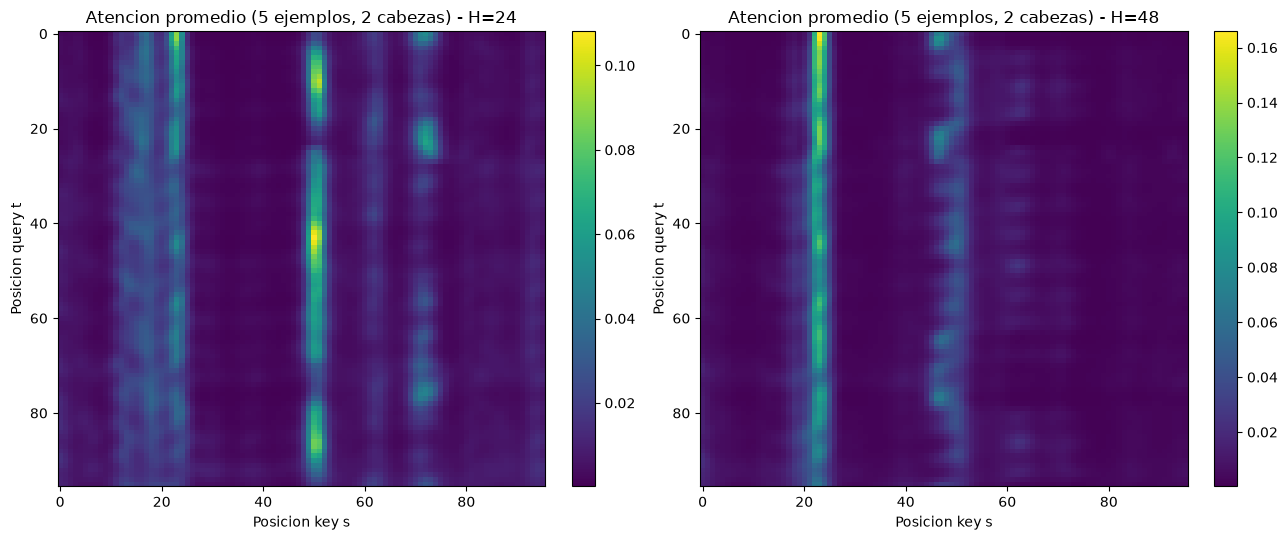

In [9]:
N_EXAMPLES = 5
attn_avg = {}
cls_attn_by_lag = {}

for H, model, X_vl in [(24, trf_24, X_vl_24), (48, trf_48, X_vl_48)]:
    model.eval()
    with torch.no_grad():
        X_in, _, _ = prepare(X_vl[:N_EXAMPLES])                 # misma entrada que en entrenamiento
        _, attn = model(X_in, return_attn=True)                 # (5, n_heads, L, L)
    attn_avg[H] = attn.mean(dim=(0, 1))                        # promedio ejemplos y cabezas -> (L, L)
    cls_row = attn_avg[H][0]                                   # atencion desde la posicion 0 (CLS)
    # cls_attn_by_lag[H][k-1] = atencion al lag k  (lag k <-> posicion L-k)
    cls_attn_by_lag[H] = cls_row.flip(0).numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, H in zip(axes, (24, 48)):
    im = ax.imshow(attn_avg[H].numpy(), cmap="viridis", aspect="auto")
    ax.set(title=f"Atencion promedio (5 ejemplos, 2 cabezas) - H={H}",
           xlabel="Posicion key s", ylabel="Posicion query t")
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

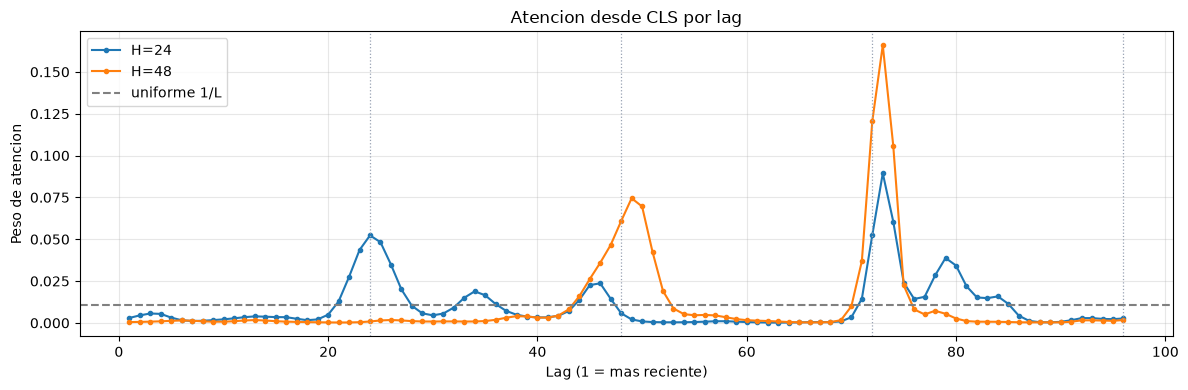

H=24: top 10 lags con mayor atencion desde CLS
  lag 73  (posicion 23):  0.08942
  lag 74  (posicion 22):  0.06057
  lag 72  (posicion 24):  0.05253
  lag 24  (posicion 72):  0.05229
  lag 25  (posicion 71):  0.04823
  lag 23  (posicion 73):  0.04357
  lag 79  (posicion 17):  0.03880
  lag 26  (posicion 70):  0.03487
  lag 80  (posicion 16):  0.03427
  lag 78  (posicion 18):  0.02836
H=48: top 10 lags con mayor atencion desde CLS
  lag 73  (posicion 23):  0.16593
  lag 72  (posicion 24):  0.12058
  lag 74  (posicion 22):  0.10593
  lag 49  (posicion 47):  0.07448
  lag 50  (posicion 46):  0.06956
  lag 48  (posicion 48):  0.06085
  lag 47  (posicion 49):  0.04658
  lag 51  (posicion 45):  0.04237
  lag 71  (posicion 25):  0.03692
  lag 46  (posicion 50):  0.03594


In [10]:
TOP_K = 10
lags_axis = np.arange(1, L + 1)

fig, ax = plt.subplots(figsize=(12, 4))
for H in (24, 48):
    ax.plot(lags_axis, cls_attn_by_lag[H], marker=".", label=f"H={H}")
ax.axhline(1 / L, color="gray", linestyle="--", label="uniforme 1/L")
for daily_lag in (24, 48, 72, 96):
    ax.axvline(daily_lag, color="#98A2B3", linestyle=":", linewidth=0.9)
ax.set(title="Atencion desde CLS por lag", xlabel="Lag (1 = mas reciente)", ylabel="Peso de atencion")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

for H in (24, 48):
    order = np.argsort(cls_attn_by_lag[H])[::-1][:TOP_K]
    print(f"H={H}: top {TOP_K} lags con mayor atencion desde CLS")
    for k in order:
        print(f"  lag {k + 1:>2}  (posicion {L - (k + 1):>2}):  {cls_attn_by_lag[H][k]:.5f}")

In [11]:
# Se guardan resultados para el Task 4
with open(RESULTS_DIR / "transformer_metrics.json", "w") as fh:
    json.dump(transformer_metrics, fh, indent=2)
with open(RESULTS_DIR / "transformer_loss.json", "w") as fh:
    json.dump({"24": trf_loss_24, "48": trf_loss_48}, fh, indent=2)
for H in (24, 48):
    np.save(RESULTS_DIR / f"cls_attention_{H}.npy", cls_attn_by_lag[H])
print("Resultados guardados en", RESULTS_DIR.resolve())

Resultados guardados en C:\Users\richi\Documents\2026_S2_Local\Deep-Learning\app\results


## Verificacion oficial del Task 3

In [12]:
# Verificar shapes
_trf_test = TransformerForecaster(d_model=32, n_heads=2, d_ff=64, L=96)
_x_test = torch.randn(4, 96)
_pred_test, _attn_test = _trf_test(_x_test, return_attn=True)
assert _pred_test.shape == (4,), \
    f"pred shape incorrecto: {_pred_test.shape}"
assert _attn_test.shape == (4, 2, 96, 96), \
    f"attn shape incorrecto: {_attn_test.shape}"

# Verificar que la atencion suma 1 por fila
row_sums = _attn_test[0, 0].sum(-1)
assert torch.allclose(row_sums, torch.ones(96), atol=1e-4), \
    "Los pesos de atencion no suman 1 por fila"

print(f"Task 3: CORRECTO")
print(f"  attn_w shape: {_attn_test.shape}")
print(f"  row sums OK: {row_sums.min().item():.4f} a {row_sums.max().item():.4f}")

Task 3: CORRECTO
  attn_w shape: torch.Size([4, 2, 96, 96])
  row sums OK: 1.0000 a 1.0000


## Preguntas de analisis

### Task 3.3d - Posiciones con mayor atencion desde CLS

> "Identifique cuales posiciones de la secuencia reciben mayor atencion desde la posicion 0 (el token CLS). Exprese esas posiciones como lags respecto al final de la ventana (lag 1 = el valor mas reciente, lag 96 = el valor mas antiguo)."

**Respuesta:** Como referencia, una atencion uniforme daria $1/96 \approx 0.0104$ por posicion. Estas son las posiciones con mas atencion (promedio de 5 ejemplos de validacion y 2 cabezas):

| Rank | $H=24$: lag (posicion) | peso | $H=48$: lag (posicion) | peso |
|---|---|---|---|---|
| 1 | 73 (23) | 0.0894 | 73 (23) | 0.1659 |
| 2 | 74 (22) | 0.0606 | 72 (24) | 0.1206 |
| 3 | 72 (24) | 0.0525 | 74 (22) | 0.1059 |
| 4 | 24 (72) | 0.0523 | 49 (47) | 0.0745 |
| 5 | 25 (71) | 0.0482 | 50 (46) | 0.0696 |
| 6 | 23 (73) | 0.0436 | 48 (48) | 0.0609 |
| 7 | 79 (17) | 0.0388 | 47 (49) | 0.0466 |
| 8 | 26 (70) | 0.0349 | 51 (45) | 0.0424 |
| 9 | 80 (16) | 0.0343 | 71 (25) | 0.0369 |
| 10 | 78 (18) | 0.0284 | 46 (50) | 0.0359 |

- **$H=24$:** la atencion se agrupa alrededor de los lags **72-74** (~3 dias atras) y **23-26** (~1 dia atras). Hay un grupo secundario en 78-80. Las ventanas de ±3 lags alrededor de 24 y 72 concentran 0.239 y 0.245 de la atencion total.
- **$H=48$:** la atencion es mas concentrada y cae sobre los lags **72-74** y **46-51** (~2 dias atras). El 83% de la atencion total esta a ±3 lags de un multiplo de 24 (0.463 alrededor de 72 y 0.356 alrededor de 48).
- **Lags recientes:** en ambos modelos, los lags 1-3 reciben casi nada (suma 0.013 con $H=24$ y 0.002 con $H=48$).
- **Conclusion:** desde CLS, el modelo mira sobre todo posiciones separadas por multiplos de ~24 h, es decir, la misma hora del dia en dias anteriores.

## Registro de uso limitado de IA generativa

### Prompt 1 — Estructura y código de los notebooks

**Prompt utilizado:** "¿Puedes hacer los notebooks con la estructura de código que se pide en ellos? Aún sin responder, pero con el código que se pide, para ya tener un orden de estos."

**Por qué funcionó:**

- **Limitó el alcance:** se pidió solo el código que exige el PDF, dejando las preguntas de análisis sin responder. La respuesta se enfocó en implementar lo solicitado sin mezclarlo con la interpretación de resultados.
- **Usó el PDF como referencia:** los esqueletos, docstrings y celdas de verificación se tomaron directamente del documento del laboratorio.
- **Pidió orden:** un notebook por task, cada uno autocontenido, lo que facilita revisar cada entrega por separado.